In [6]:
!pip uninstall -y sympy torch torchvision torchaudio

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Found existing installation: torchvision 0.25.0+cpu
Uninstalling torchvision-0.25.0+cpu:
  Successfully uninstalled torchvision-0.25.0+cpu
Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu


In [9]:
!pip install sympy==1.13.1
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 17.8 MB/s eta 0:00:00


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 20.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 65.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 70.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 44.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 86.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━ 110.5/121.6 MB 146.3 MB/s eta 0:00:01^C


In [1]:
# ============================================================
# DrLIM (Dimensionality Reduction by Learning an Invariant Mapping)
# Full End-to-End PyTorch Reproduction
# ============================================================

# Paper:
# Raia Hadsell, Sumit Chopra, Yann LeCun
# CVPR 2006

# This implementation reproduces:
# 1. Siamese architecture
# 2. Contrastive loss
# 3. MNIST manifold learning
# 4. Shift-invariant embeddings
# 5. LLE comparison
# ============================================================

# ============================================================
# INSTALLS
# ============================================================

# pip install torch torchvision scikit-learn matplotlib tqdm

# ============================================================
# IMPORTS
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms

from sklearn.manifold import LocallyLinearEmbedding


In [3]:
# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [4]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


In [5]:
# ============================================================
# LOAD MNIST
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 60000
Test size: 10000


In [6]:
# ============================================================
# KEEP ONLY DIGITS 4 AND 9
# SAME AS PAPER
# ============================================================

selected_digits = [4, 9]

def filter_dataset(dataset):

    images = []
    labels = []

    for image, label in dataset:

        if label in selected_digits:

            images.append(image)
            labels.append(label)

    images = torch.stack(images)
    labels = torch.tensor(labels)

    return images, labels

train_images, train_labels = filter_dataset(train_dataset)
test_images, test_labels = filter_dataset(test_dataset)

print(train_images.shape)
print(test_images.shape)


torch.Size([11791, 1, 28, 28])
torch.Size([1991, 1, 28, 28])


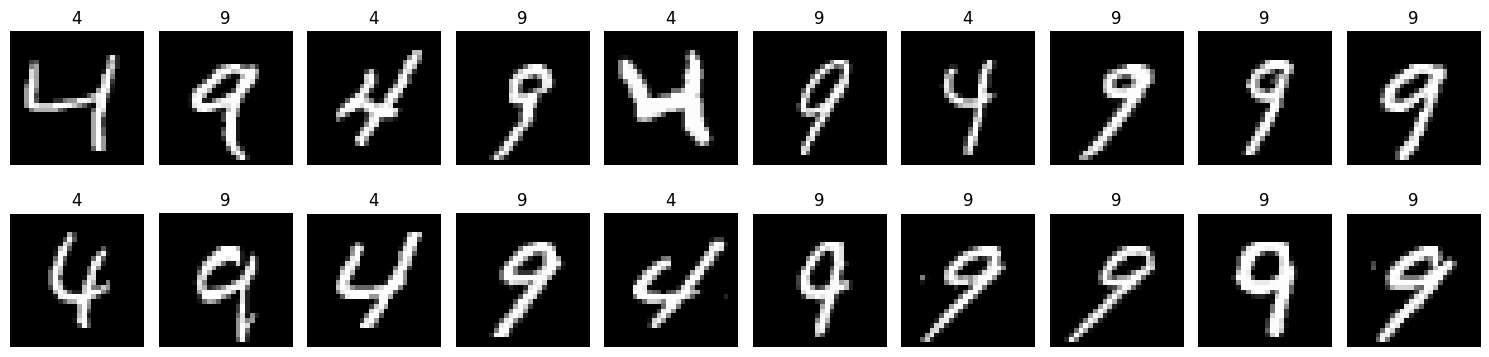

In [7]:
# ============================================================
# VISUALIZE SAMPLES
# ============================================================

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    axes[0, i].imshow(train_images[i][0], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(str(train_labels[i].item()))

for i in range(10):

    axes[1, i].imshow(train_images[i + 100][0], cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(str(train_labels[i + 100].item()))

plt.tight_layout()
plt.show()



In [8]:
# ============================================================
# SHIFT AUGMENTATION
# REPRODUCING PAPER EXPERIMENT
# ============================================================

def shift_image(image, shift_pixels):

    return torch.roll(image, shifts=shift_pixels, dims=2)

shifts = [-6, -3, 0, 3, 6]

augmented_images = []
augmented_labels = []

# Use subset for faster training

subset_size = 3000

for image, label in zip(
    train_images[:subset_size],
    train_labels[:subset_size]
):

    for shift in shifts:

        shifted_image = shift_image(image, shift)

        augmented_images.append(shifted_image)
        augmented_labels.append(label)

augmented_images = torch.stack(augmented_images)
augmented_labels = torch.tensor(augmented_labels)

print("Augmented dataset shape:", augmented_images.shape)


Augmented dataset shape: torch.Size([15000, 1, 28, 28])


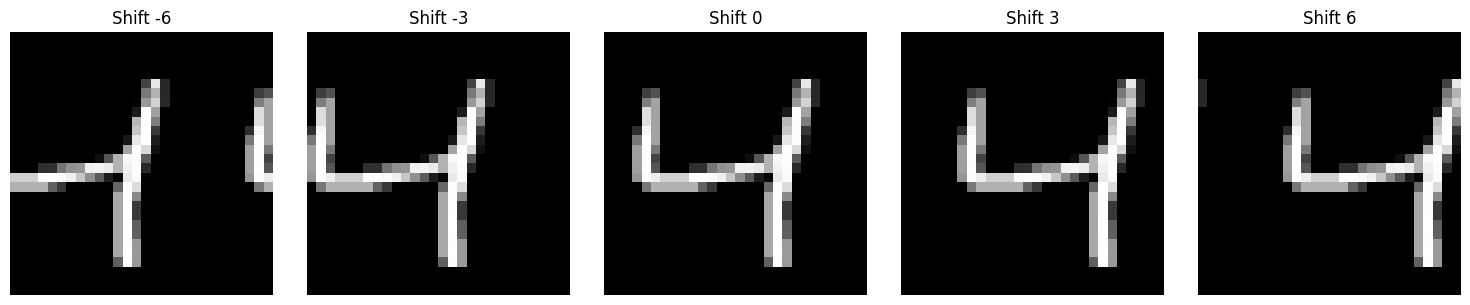

In [9]:
# ============================================================
# VISUALIZE SHIFTED DIGITS
# ============================================================

sample_image = train_images[0]

fig, axes = plt.subplots(1, len(shifts), figsize=(15, 3))

for i, shift in enumerate(shifts):

    shifted = shift_image(sample_image, shift)

    axes[i].imshow(shifted[0], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Shift {shift}")

plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# SIAMESE PAIR DATASET
# ============================================================

class SiameseMNIST(Dataset):

    def __init__(self, images, labels):

        self.images = images
        self.labels = labels

        self.label_to_indices = {}

        for idx, label in enumerate(labels):

            label = int(label)

            if label not in self.label_to_indices:

                self.label_to_indices[label] = []

            self.label_to_indices[label].append(idx)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        image1 = self.images[idx]
        label1 = int(self.labels[idx])

        same_class = random.randint(0, 1)

        # Similar pair
        if same_class:

            idx2 = random.choice(
                self.label_to_indices[label1]
            )

            target = 0.0

        # Dissimilar pair
        else:

            other_label = 9 if label1 == 4 else 4

            idx2 = random.choice(
                self.label_to_indices[other_label]
            )

            target = 1.0

        image2 = self.images[idx2]

        return (
            image1,
            image2,
            torch.tensor(target, dtype=torch.float32)
        )

train_pairs = SiameseMNIST(
    augmented_images,
    augmented_labels
)

train_loader = DataLoader(
    train_pairs,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))


Train batches: 118


In [11]:
# ============================================================
# DRLIM EMBEDDING NETWORK
# ARCHITECTURE FROM PAPER
# ============================================================

class EmbeddingNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.convnet = nn.Sequential(

            # C1
            nn.Conv2d(
                in_channels=1,
                out_channels=15,
                kernel_size=6
            ),

            nn.ReLU(),

            # S2
            nn.MaxPool2d(2),

            # C3
            nn.Conv2d(
                in_channels=15,
                out_channels=30,
                kernel_size=9
            ),

            nn.ReLU()
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(30, 20),

            nn.ReLU(),

            # 2D embedding
            nn.Linear(20, 2)
        )

    def forward(self, x):

        x = self.convnet(x)
        x = self.fc(x)

        return x


In [12]:
# ============================================================
# SIAMESE NETWORK
# ============================================================

class SiameseNetwork(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding_net = EmbeddingNet()

    def forward(self, x1, x2):

        z1 = self.embedding_net(x1)
        z2 = self.embedding_net(x2)

        return z1, z2


In [13]:
# ============================================================
# CONTRASTIVE LOSS
# EXACT DRLIM LOSS
# ============================================================

class ContrastiveLoss(nn.Module):

    def __init__(self, margin=1.0):

        super().__init__()

        self.margin = margin

    def forward(self, z1, z2, target):

        distance = F.pairwise_distance(z1, z2)

        # Similar loss
        similar_loss = (
            (1 - target)
            * 0.5
            * torch.pow(distance, 2)
        )

        # Dissimilar loss
        dissimilar_loss = (
            target
            * 0.5
            * torch.pow(
                torch.clamp(
                    self.margin - distance,
                    min=0.0
                ),
                2
            )
        )

        loss = similar_loss + dissimilar_loss

        return loss.mean()


In [14]:
# ============================================================
# INITIALIZE MODEL
# ============================================================

model = SiameseNetwork().to(device)

criterion = ContrastiveLoss(margin=1.0)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(model)



SiameseNetwork(
  (embedding_net): EmbeddingNet(
    (convnet): Sequential(
      (0): Conv2d(1, 15, kernel_size=(6, 6), stride=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(15, 30, kernel_size=(9, 9), stride=(1, 1))
      (4): ReLU()
    )
    (fc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=30, out_features=20, bias=True)
      (2): ReLU()
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)


In [16]:
# ============================================================
# DRLIM EMBEDDING NETWORK
# FIXED VERSION
# ============================================================

class EmbeddingNet(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # Convolutional Backbone
        # ----------------------------------------------------

        self.convnet = nn.Sequential(

            # C1
            nn.Conv2d(
                in_channels=1,
                out_channels=15,
                kernel_size=6
            ),

            nn.ReLU(),

            # S2
            nn.MaxPool2d(kernel_size=2),

            # C3
            nn.Conv2d(
                in_channels=15,
                out_channels=30,
                kernel_size=9
            ),

            nn.ReLU()
        )

        # ----------------------------------------------------
        # Automatically infer flatten size
        # ----------------------------------------------------

        with torch.no_grad():

            dummy = torch.zeros(1, 1, 28, 28)

            dummy_output = self.convnet(dummy)

            self.flatten_dim = dummy_output.view(1, -1).shape[1]

        print("Flatten dimension:", self.flatten_dim)

        # ----------------------------------------------------
        # Fully Connected Projection Head
        # ----------------------------------------------------

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(self.flatten_dim, 20),

            nn.ReLU(),

            # Final 2D embedding
            nn.Linear(20, 2)
        )

    def forward(self, x):

        x = self.convnet(x)

        x = self.fc(x)

        return x


# ============================================================
# SIAMESE NETWORK
# ============================================================

class SiameseNetwork(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding_net = EmbeddingNet()

    def forward(self, x1, x2):

        z1 = self.embedding_net(x1)

        z2 = self.embedding_net(x2)

        return z1, z2


# ============================================================
# INITIALIZE MODEL
# ============================================================

model = SiameseNetwork().to(device)

print(model)

Flatten dimension: 270
SiameseNetwork(
  (embedding_net): EmbeddingNet(
    (convnet): Sequential(
      (0): Conv2d(1, 15, kernel_size=(6, 6), stride=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(15, 30, kernel_size=(9, 9), stride=(1, 1))
      (4): ReLU()
    )
    (fc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=270, out_features=20, bias=True)
      (2): ReLU()
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)


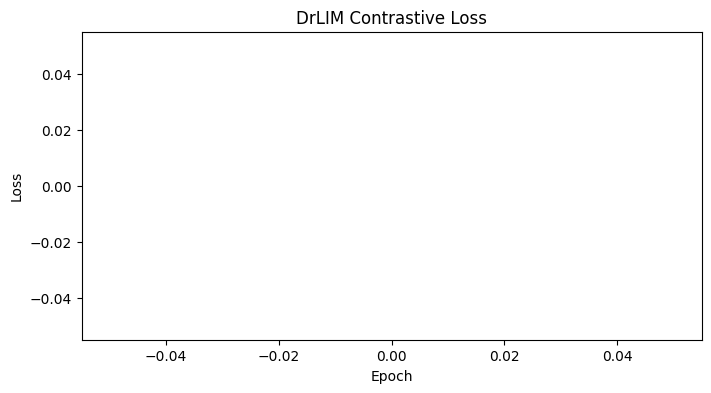

Embeddings shape: (1991, 2)


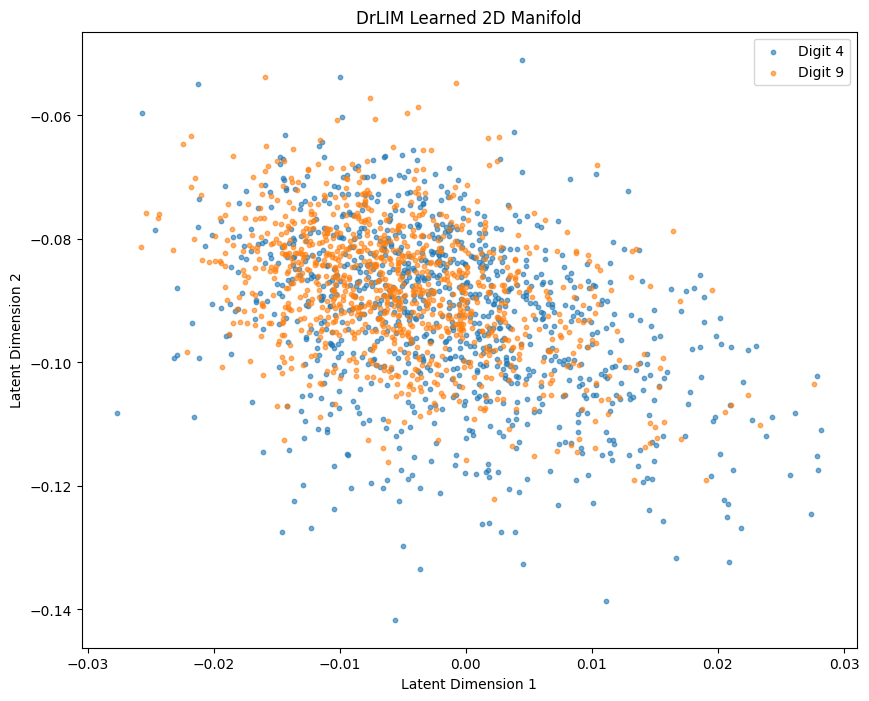

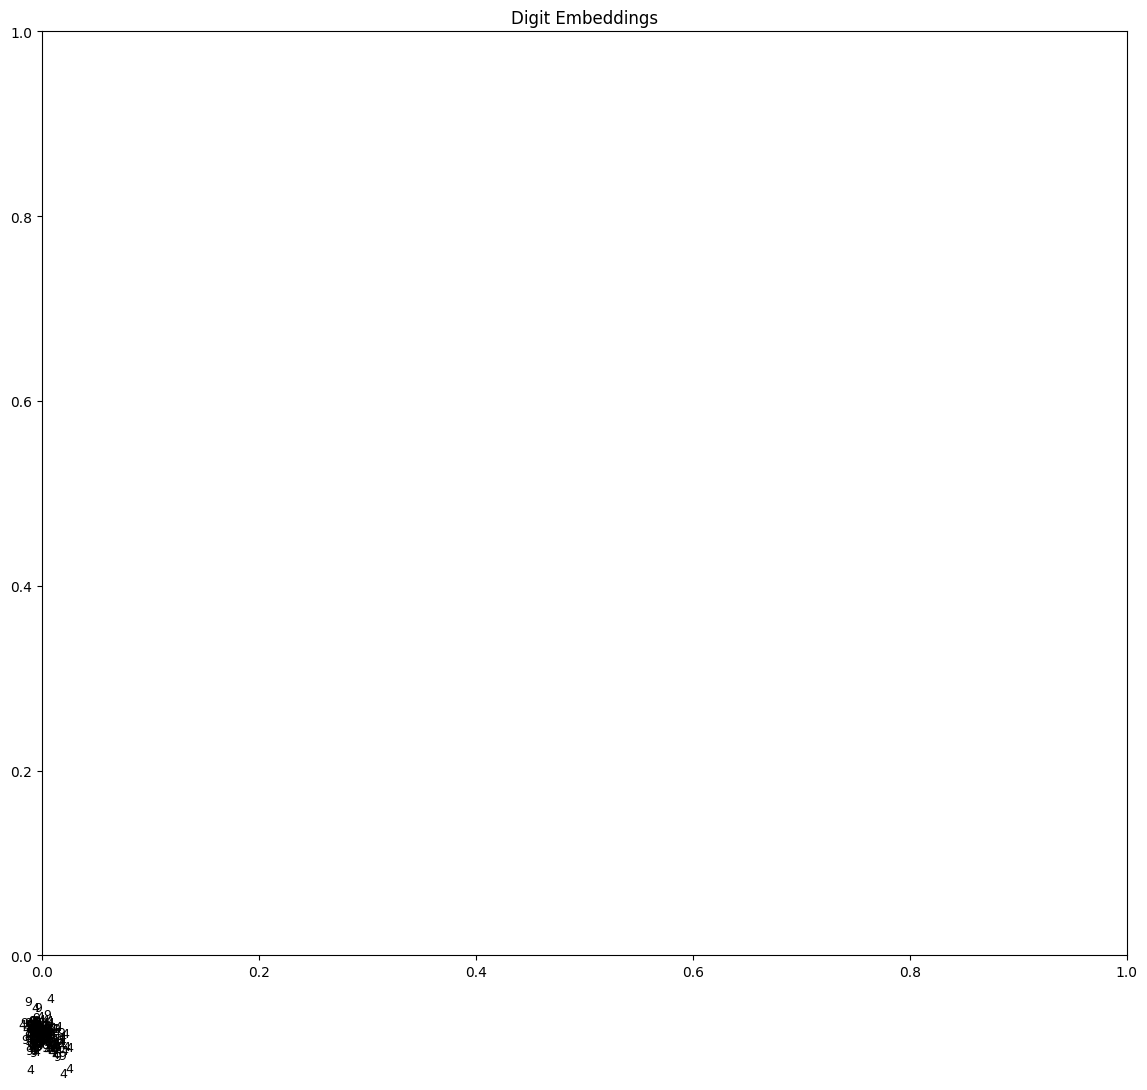

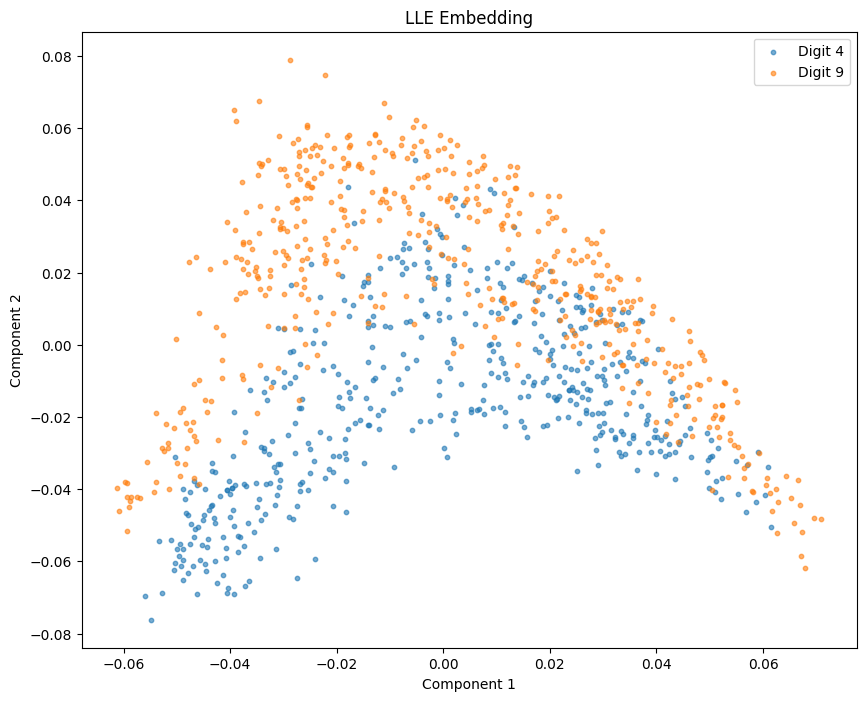

Model saved.
Flatten dimension: 270
Model loaded successfully.
DrLIM reproduction completed.


In [17]:





# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(history)

plt.title("DrLIM Contrastive Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

# ============================================================
# GENERATE EMBEDDINGS
# ============================================================

model.eval()

embeddings = []
labels = []

with torch.no_grad():

    for image, label in zip(
        test_images[:2000],
        test_labels[:2000]
    ):

        image = image.unsqueeze(0).to(device)

        embedding = model.embedding_net(image)

        embeddings.append(
            embedding.cpu().numpy()[0]
        )

        labels.append(label.item())

embeddings = np.array(embeddings)
labels = np.array(labels)

print("Embeddings shape:", embeddings.shape)

# ============================================================
# VISUALIZE LEARNED MANIFOLD
# ============================================================

plt.figure(figsize=(10, 8))

for digit in [4, 9]:

    idx = labels == digit

    plt.scatter(
        embeddings[idx, 0],
        embeddings[idx, 1],
        s=10,
        alpha=0.6,
        label=f"Digit {digit}"
    )

plt.title("DrLIM Learned 2D Manifold")

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.legend()

plt.show()

# ============================================================
# VISUALIZE INDIVIDUAL EMBEDDINGS
# ============================================================

plt.figure(figsize=(14, 12))

for i in range(200):

    plt.text(
        embeddings[i, 0],
        embeddings[i, 1],
        str(labels[i]),
        fontsize=9
    )

plt.title("Digit Embeddings")

plt.show()

# ============================================================
# COMPARE WITH LLE
# ============================================================

subset = test_images[:1000].view(1000, -1).numpy()

lle = LocallyLinearEmbedding(
    n_components=2,
    n_neighbors=10
)

lle_embeddings = lle.fit_transform(subset)

# ============================================================
# VISUALIZE LLE
# ============================================================

plt.figure(figsize=(10, 8))

for digit in [4, 9]:

    idx = labels[:1000] == digit

    plt.scatter(
        lle_embeddings[idx, 0],
        lle_embeddings[idx, 1],
        s=10,
        alpha=0.6,
        label=f"Digit {digit}"
    )

plt.title("LLE Embedding")

plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.legend()

plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    "drlim_mnist.pth"
)

print("Model saved.")

# ============================================================
# LOAD MODEL
# ============================================================

loaded_model = SiameseNetwork().to(device)

loaded_model.load_state_dict(
    torch.load("drlim_mnist.pth")
)

loaded_model.eval()

print("Model loaded successfully.")

# ============================================================
# EXPECTED RESULTS
# ============================================================

"""
Expected observations:

1. DrLIM manifold:
   - Smooth
   - Organized
   - Shift invariant
   - Similar digits grouped together

2. LLE:
   - More fragmented
   - Less coherent
   - Sensitive to distortions

3. Contrastive learning:
   - Similar pairs pulled together
   - Dissimilar pairs pushed apart

This reproduces the key ideas from the paper.
"""

# ============================================================
# OPTIONAL IMPROVEMENTS
# ============================================================

"""
Possible extensions:

1. NORB experiment
2. 3D manifold visualization
3. Interactive embeddings
4. t-SNE comparison
5. UMAP comparison
6. ResNet encoder
7. SimCLR-style training
8. Hard negative mining
"""

print("DrLIM reproduction completed.")